<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/GradientBoostingRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

<Axes: ylabel='Density'>

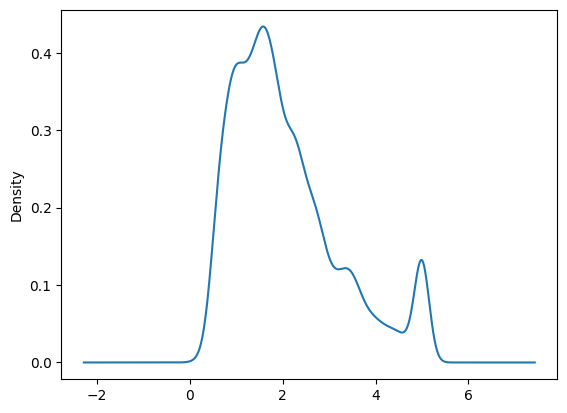

In [5]:
df['MedHouseVal'].plot(kind='kde')

In [6]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('MedHouseVal', axis=1), df['MedHouseVal'], test_size=0.2, random_state=42)

In [7]:
gbr=GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [8]:
r2_score(y_test, gbr.predict(x_test))
#

0.7756446042829697

In [9]:
gbr=GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [10]:
r2_score(y_test, gbr.predict(x_test))

0.8004451261281281

In [11]:
gbr=GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=300, random_state=42)

In [12]:
r2_score(y_test, gbr.predict(x_test))

0.8102267390771959

In [13]:
gbr=GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=500, random_state=42)

In [14]:
r2_score(y_test, gbr.predict(x_test))

0.8403185953429391

In [15]:
gbr=GradientBoostingRegressor(n_estimators=500, learning_rate=0.001, max_depth=6, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.001, max_depth=6, n_estimators=500,
                          random_state=42)

In [16]:
r2_score(y_test, gbr.predict(x_test))

0.4253553916191305

In [17]:
gbr=GradientBoostingRegressor(n_estimators=500, learning_rate=0.25, max_depth=4, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.25, max_depth=4, n_estimators=500,
                          random_state=42)

In [18]:
r2_score(y_test, gbr.predict(x_test))

0.8361777331755037

# GradientBoostingRegressor — Revision Notes

## 1. What is Gradient Boosting?

**Gradient Boosting Regressor** is an ensemble machine learning algorithm used for **regression problems**.

It combines multiple **weak decision trees** to create a strong predictive model.

Unlike Random Forest, where trees are generally built independently, Gradient Boosting builds trees **sequentially**.

Each new tree tries to **correct the errors made by the previous trees**.

---

# 2. Basic Idea

The main idea is:

```text
Start with a simple prediction
        ↓
Calculate errors
        ↓
Train a tree to predict those errors
        ↓
Update the prediction
        ↓
Calculate remaining errors
        ↓
Train another tree
        ↓
Repeat
        ↓
Final prediction
Memory Trick

Every new tree tries to fix the mistakes of the previous trees.

3. How GradientBoostingRegressor Works

Suppose we want to predict house prices.

Step 1: Initial Prediction

The model starts with a simple prediction.

For regression, this is generally related to the average target value.

Example:

Actual prices:

200
250
300
350

Mean = 275

The initial model may predict:

275
275
275
275
Step 2: Calculate Errors

The model calculates the difference between actual and predicted values.

Error = Actual Value - Predicted Value

Example:

Actual     Prediction     Error

200        275            -75
250        275            -25
300        275             25
350        275             75

These errors are called residuals.

Step 3: Train a Decision Tree

A small decision tree is trained to learn these errors.

The tree tries to predict:

Residual / Error

instead of directly predicting the original target.

Step 4: Update the Prediction

The prediction is updated using the new tree.

Conceptually:

New Prediction =
Old Prediction + Learning Rate × Tree Prediction

The learning rate controls how much the new tree affects the prediction.

Step 5: Repeat

Another tree is trained to correct the remaining errors.

Tree 1 → correct initial errors

Tree 2 → correct remaining errors

Tree 3 → correct remaining errors

Tree 4 → correct remaining errors

...

Final Model

The process continues for the specified number of trees.

4. Why is it called "Gradient" Boosting?

Gradient Boosting uses the idea of gradient descent to minimize a loss function.

The model tries to find the direction in which the prediction error decreases.

For example, with regression:

Loss Function → MSE

The algorithm adds trees in a way that gradually reduces the loss.

Therefore:

Gradient
    ↓
Optimization using gradients

Boosting
    ↓
Sequentially improving weak learners
5. Why is it called "Boosting"?

Boosting means combining several weak learners to create a strong learner.

A single small decision tree may not perform very well.

But:

Weak Tree
   +
Weak Tree
   +
Weak Tree
   +
Weak Tree
   ↓
Strong Model

Gradient Boosting improves the model step-by-step.

6. Python Implementation

Import the algorithm:

from sklearn.ensemble import GradientBoostingRegressor

Create the model:

gbr = GradientBoostingRegressor()

Train the model:

gbr.fit(x_train, y_train)

Make predictions:

y_pred = gbr.predict(x_test)
7. Basic Example
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(x_train, y_train)

y_pred = gbr.predict(x_test)
8. Important Hyperparameters

The most important hyperparameters are:

n_estimators
learning_rate
max_depth
min_samples_split
min_samples_leaf
subsample
max_features
loss
random_state
9. n_estimators
Meaning

n_estimators specifies the number of boosting stages / trees.

GradientBoostingRegressor(n_estimators=100)

Example:

n_estimators = 100

→ 100 boosting stages
Higher value
Higher n_estimators
        ↓
More trees
        ↓
More learning
        ↓
Higher computation
        ↓
Possible overfitting
Lower value
Lower n_estimators
        ↓
Fewer trees
        ↓
Faster training
        ↓
May underfit
10. learning_rate
Meaning

Controls the contribution of each tree.

GradientBoostingRegressor(learning_rate=0.1)

Conceptually:

New Prediction =
Old Prediction +
learning_rate × Tree Prediction
Small learning rate

Example:

learning_rate=0.01

The model learns slowly.

Usually, more trees are required.

Large learning rate

Example:

learning_rate=0.2

The model learns faster.

But it can increase the risk of overfitting.

Important relationship
Lower learning_rate
        +
Higher n_estimators
        ↓
Often better generalization
11. max_depth
Meaning

Controls the maximum depth of the individual decision trees.

GradientBoostingRegressor(max_depth=3)
Small depth
Small max_depth
      ↓
Simple trees
      ↓
Lower complexity
Large depth
Large max_depth
      ↓
Complex trees
      ↓
Can learn complicated patterns
      ↓
Higher overfitting risk

A small value such as:

max_depth=2

or

max_depth=3

is commonly a good starting point.

12. min_samples_split
Meaning

Minimum number of samples required to split an internal node.

GradientBoostingRegressor(min_samples_split=2)

If the number is increased:

Higher min_samples_split
        ↓
Fewer splits
        ↓
Simpler trees
        ↓
Less overfitting
13. min_samples_leaf
Meaning

Minimum number of samples required in a leaf node.

GradientBoostingRegressor(min_samples_leaf=1)

Increasing this value can make the trees less complex.

Example:

min_samples_leaf=5

means a leaf generally needs at least 5 samples.

14. subsample
Meaning

Determines the fraction of training samples used for fitting each individual tree.

Example:

GradientBoostingRegressor(subsample=0.8)

Approximately:

80% of training data
        ↓
Used for each boosting stage

Default:

subsample = 1.0

means all training samples are used.

Using a value below 1.0 can introduce randomness and may help reduce overfitting.

15. max_features
Meaning

Controls the number of features considered when looking for the best split.

Possible values include:

max_features=None
max_features='sqrt'
max_features='log2'

or an integer.

Using fewer features can reduce model complexity and computation.

16. loss
Meaning

Specifies the loss function that the model tries to minimize.

Common options include:

squared_error
absolute_error
huber
quantile
squared_error

Common choice for normal regression problems.

loss='squared_error'
absolute_error

Can be more robust to outliers.

loss='absolute_error'
huber

Combines properties of squared error and absolute error.

loss='huber'
quantile

Useful when you want to predict a particular quantile instead of only the expected value.

loss='quantile'
17. random_state

Used to make results reproducible when randomness is involved.

GradientBoostingRegressor(random_state=42)

Using the same random_state generally gives repeatable results for the same data and configuration.

18. Important Hyperparameters to Remember

For exams and practical ML work, focus mainly on:

n_estimators
learning_rate
max_depth
min_samples_split
min_samples_leaf
subsample
loss

The most important three are:

1. n_estimators
2. learning_rate
3. max_depth
19. What Type of Data is GradientBoostingRegressor Used For?

GradientBoostingRegressor is mainly useful for:

Structured / Tabular Data

Examples:

House price dataset
Student performance dataset
Employee salary dataset
Car price dataset
Sales dataset
Financial dataset
Energy consumption dataset

It works especially well when the dataset contains:

Numerical Features
        +
Encoded Categorical Features
        +
Non-linear Relationships
20. Example: Student Performance

Suppose we have:

study_time_hours
attendance_percent
sleep_hours
previous_grade

Target:

final_exam_score

Gradient Boosting can learn complex relationships.

For example:

Study Hours ↑
      ↓
Exam Score ↑

But it can also learn interactions such as:

Study Hours ↑
        +
Very Low Sleep
        ↓
Performance may decrease

This is one reason tree-based boosting models are powerful.

21. Does GradientBoostingRegressor Require Feature Scaling?

Generally:

No, GradientBoostingRegressor does not require feature scaling.

For example, you usually don't need:

StandardScaler()

or:

MinMaxScaler()

just because you are using Gradient Boosting.

This is because decision-tree-based models make predictions based on feature split conditions.

22. Does it Handle Categorical Data Directly?

In standard sklearn.ensemble.GradientBoostingRegressor, categorical variables generally need to be converted into numerical form first.

For example:

Gender

Male
Female

can be encoded using:

OneHotEncoder()

or another appropriate encoding method.

23. Advantages
✓ Strong performance on tabular data

✓ Captures non-linear relationships

✓ Captures feature interactions

✓ Usually provides high predictive accuracy

✓ Does not require feature scaling

✓ Can use different loss functions

✓ Works well with medium-sized datasets

✓ More powerful than a single decision tree
24. Disadvantages
✗ Can overfit

✗ Training is sequential

✗ Can be slower than Random Forest

✗ Hyperparameter tuning is important

✗ Less interpretable than Linear Regression

✗ Performance can be affected by noisy data

✗ Not usually the first choice for raw images/audio/text
25. Gradient Boosting vs Random Forest
Feature	Random Forest	Gradient Boosting
Tree construction	Mostly parallel	Sequential
Main idea	Reduce variance	Reduce errors/loss
Each tree corrects previous tree?	No	Yes
Training	Usually faster	Usually slower
Overfitting	Relatively robust	Needs careful tuning
Tabular data	Excellent	Excellent
Scaling required	No	No
Easy difference
Random Forest:

Tree 1 ──┐
Tree 2 ──┤
Tree 3 ──┤ → Combine → Prediction
Tree 4 ──┘


Gradient Boosting:

Tree 1
  ↓
Tree 2 → Correct Tree 1
  ↓
Tree 3 → Correct previous errors
  ↓
Tree 4 → Correct remaining errors
  ↓
Final Prediction
26. Gradient Boosting vs Linear Regression
Linear Regression

Assumes a linear relationship:

X → Y

Example:

More experience → Higher salary
Gradient Boosting

Can learn complex non-linear relationships:

X1 + X2 + X3
       ↓
Complex decision boundaries
       ↓
Prediction

Therefore, Gradient Boosting is often better when relationships are not simply linear.

27. When Should I Use GradientBoostingRegressor?

Consider using it when:

Target is continuous
        ↓
Dataset is tabular
        ↓
Relationships are non-linear
        ↓
You want strong predictive performance
        ↓
Dataset is not extremely huge
        ↓
Gradient Boosting is a good candidate

Examples:

Predict house price
Predict salary
Predict student marks
Predict sales
Predict electricity consumption
Predict insurance cost
Predict car price
28. When Should I Avoid It?

Avoid using it as the first choice when:

Data is extremely large

because training many sequential trees can become expensive.

Also, if your input is:

Raw images
Raw audio
Raw video
Raw text

specialized deep learning or NLP models may be more suitable.

29. Basic Model Evaluation

For regression, common metrics are:

MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

MAE tells us the average absolute prediction error.

MSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

MSE gives more penalty to large errors.

RMSE
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

RMSE is in the same unit as the target variable.

R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

Higher R² generally indicates a better fit.

30. Example Complete Code
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Create model
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gbr.fit(x_train, y_train)

# Predict
y_pred = gbr.predict(x_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
31. Hyperparameter Tuning

You can tune Gradient Boosting using:

GridSearchCV

Example:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

For faster experiments, keep the parameter grid small.

32. Overfitting Control

Gradient Boosting can overfit.

Ways to control it:

1. Reduce max_depth

2. Reduce learning_rate

3. Increase min_samples_leaf

4. Increase min_samples_split

5. Use subsample < 1.0

6. Use an appropriate number of estimators

7. Use cross-validation

A common strategy:

Lower learning_rate
        +
More estimators
        +
Small tree depth
        ↓
Better generalization

But these values should still be selected using validation/cross-validation.

33. Feature Importance

GradientBoostingRegressor can provide feature importance.

importance = gbr.feature_importances_

print(importance)

You can visualize it:

import matplotlib.pyplot as plt

plt.bar(x_train.columns, gbr.feature_importances_)
plt.xticks(rotation=90)
plt.show()

Higher value means the feature contributed more to the model's splitting decisions.

34. Important Difference from AdaBoost

Both are Boosting algorithms, but their learning approach differs.

AdaBoost
Focuses more on incorrectly predicted observations
Gradient Boosting
Builds the next tree to reduce the loss / residual errors

Memory trick:

AdaBoost
→ Focus on difficult observations

Gradient Boosting
→ Fit the errors/residuals
35. Important Difference from XGBoost

Gradient Boosting is the basic boosting concept.

XGBoost is a more optimized and advanced implementation of gradient boosting.

Gradient Boosting
        ↓
Basic sequential boosting approach

XGBoost
        ↓
Optimized / regularized gradient boosting implementation

XGBoost often provides additional performance and optimization features.

36. Quick Revision
Algorithm:
GradientBoostingRegressor

Type:
Supervised Learning

Problem:
Regression

Model:
Ensemble of Decision Trees

Learning:
Sequential

Main Idea:
Each new tree tries to correct previous errors.

Scaling:
Not required

Best for:
Structured / tabular data

Target:
Continuous numerical value

Important Hyperparameters:
n_estimators
learning_rate
max_depth
min_samples_split
min_samples_leaf
subsample
loss

Main Risk:
Overfitting

Main Strength:
Strong performance on non-linear tabular regression problems
37. One-Minute Revision
What is GradientBoostingRegressor?

An ensemble regression algorithm that builds decision trees sequentially, with each new tree trying to reduce the errors made by the previous trees.

How does it work?
Initial Prediction
      ↓
Calculate Errors
      ↓
Train Tree on Errors
      ↓
Update Prediction
      ↓
Calculate New Errors
      ↓
Train Next Tree
      ↓
Repeat
Mostly used for?

Structured/tabular regression problems, especially when the relationship between features and target is non-linear.

Most important hyperparameters?
n_estimators
learning_rate
max_depth
Does it need scaling?

No.

Main disadvantage?

It can overfit and training is sequential, so it can be slower than some alternatives.

38. Final Memory Formula
Gradient Boosting

Many Small Trees
       ↓
Built Sequentially
       ↓
Each Tree Corrects Errors
       ↓
Learning Rate Controls Contribution
       ↓
Combine All Trees
       ↓
Final Regression Prediction